In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r'D:\projects\mlproject1\Notebook\data\StudentsPerformance.csv')

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.shape

(1000, 8)

In [16]:
#check missing values
#check duplicate values
#check null values
#check data types
#check unique values
df['parental level of education'].unique()


array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [18]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [19]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [31]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [14]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [32]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [35]:
num_features = [feat for feat in df.columns if df[feat].dtype != 'O']
cat_features = [feat for feat in df.columns if df[feat].dtype == 'O']
print('Numerical features:', num_features)
print('length of numerical features:', len(num_features))
print('Categorical features:', cat_features)
print('length of categorical features:', len(cat_features))

Numerical features: ['math score', 'reading score', 'writing score']
length of numerical features: 3
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
length of categorical features: 5


In [36]:
#Adding two columns Total score and average score
df['Total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average_score'] = df['Total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [48]:
read_full = df[df['reading score'] == 100]['Average_score'].count()
write_full = df[df['writing score'] == 100]['Average_score'].count()
math_full = df[df['math score']==100]['Average_score'].count()
print('Number of students who scored 100 in reading:', read_full)
print('Number of students who scored 100 in writing:', write_full) 
print('Number of students who scored 100 in math:', math_full)

Number of students who scored 100 in reading: 17
Number of students who scored 100 in writing: 14
Number of students who scored 100 in math: 7


In [50]:
read_less_20 = df[df['reading score'] < 20]['Average_score'].count()
write_less_20 = df[df['writing score'] < 20]['Average_score'].count()
math_less_20 = df[df['math score'] < 20]['Average_score'].count()
print('Number of students who scored less than 20 in reading:', read_less_20)
print('Number of students who scored less than 20 in writing:', write_less_20)
print('Number of students who scored less than 20 in math:', math_less_20)

Number of students who scored less than 20 in reading: 1
Number of students who scored less than 20 in writing: 3
Number of students who scored less than 20 in math: 4


<Axes: xlabel='Average_score', ylabel='Count'>

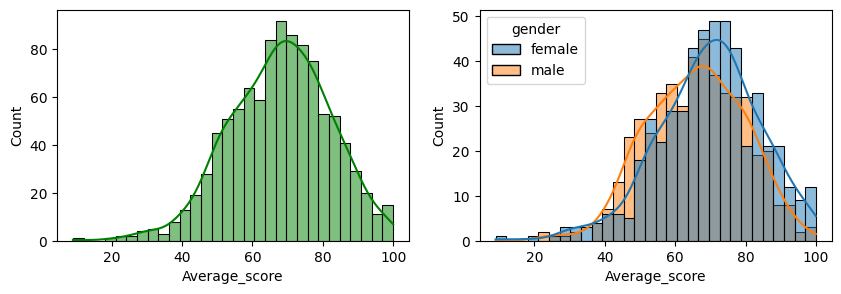

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
plt.subplot(121)
sns.histplot(data=df,x='Average_score', kde=True, bins=30,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average_score', kde=True, hue='gender', bins=30)